Os arquivos utilizados na análise a seguir estão disponíveis nos links:
1. [Repositório de Dados Eleitorais](https://www.tse.jus.br/hotsites/pesquisas-eleitorais/resultados.html)
2. [Partidos 2020 e 2024](https://github.com/programacaodinamica/analise-dados/blob/master/dados)
3. [Brasil ShapeFile IBGE](https://www.ibge.gov.br/geociencias/organizacao-do-territorio/malhas-territoriais/15774-malhas.html)
4. [Resultado Eleicoes 2024 UOL](https://noticias.uol.com.br/eleicoes/2024/apuracao/)
5.[prefeitos_mais_votados_1turno_2020.csv](https://github.com/programacaodinamica/analise-dados/blob/master/dados/prefeitos_mais_votados_1turno_2020.csv)
6.[municipios_brasileiros_tse.csv](https://github.com/programacaodinamica/analise-dados/blob/master/dados/municipios_brasileiros_tse.csv)

7.[zonas eleitorais e bairros](https://www.tre-rj.jus.br/institucional/enderecos-e-telefones/zona-eleitoral-por-municipio/rio-de-janeiro)

### Setup & Dataloading

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import unidecode
import folium
import numpy as np
from branca.colormap import LinearColormap
import matplotlib.colors as colors
import re
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

In [10]:
base_dir = os.getcwd()
pasta_eleicoes = os.path.join(base_dir, '..', 'data')

# votacao_secao_2016 = os.path.join(pasta_eleicoes,'votacao_secao_2016_RJ.csv')
# votacao_secao_2020 = os.path.join(pasta_eleicoes,'votacao_secao_2020_RJ.csv')
# votacao_secao_2024 = os.path.join(pasta_eleicoes,'votacao_secao_2024_RJ.csv')

# votos_total_rj = os.path.join(pasta_eleicoes,'votos_total_rj.csv')
votos_total_rj_bairros_previa = os.path.join(pasta_eleicoes,'votos_total_rj_bairros_previa.csv')

espectro_partido_2024 = os.path.join(pasta_eleicoes,'partidos2024.csv')

bairros_shapefile = os.path.join(pasta_eleicoes, 'Limite_de_Bairros')
ceps = os.path.join(pasta_eleicoes,'cep_unificado.csv')

api_key = "9ea08b830c03efa59657009ca8a1002f441c1fb1"

In [4]:
#alterando formato de exibição dos gráficos do Pandas
pd.options.plotting.backend = 'plotly'

In [5]:
#test variables
candidato_vererador = 13535
candidato_prefeito = 25
partido_selecao = 'PT'
cargo_selecao = 'VEREADOR'
ano = '2024'

## Load DFs

### Shapefile dos bairros

In [6]:
bairros_shp = gpd.read_file(bairros_shapefile)
bairros_shp = bairros_shp.rename(columns={'nome':'BAIRRO'})
bairros_shp = bairros_shp[['BAIRRO', 'geometry']]
bairros_shp['BAIRRO'] = bairros_shp['BAIRRO'].apply(lambda x: unidecode.unidecode(x).upper())
bairros_shp = bairros_shp.drop_duplicates()
# bairros_shp['BAIRRO'].unique()

### Criando Dataframes de Espectro

In [7]:
espectro_partido_2024_df = pd.read_csv(espectro_partido_2024, encoding='latin-1', sep=';')
espectro_partido_2024_df = espectro_partido_2024_df[['NR_PARTIDO','Espectro','SG_PARTIDO']]
espectro_partido_2024_df.columns = espectro_partido_2024_df.columns.str.upper()
espectro_partido_2024_df['ESPECTRO'] = espectro_partido_2024_df['ESPECTRO'].apply(lambda x: x.upper())
espectro_partido_2024_df = espectro_partido_2024_df.rename(columns={'SG_PARTIDO':'PARTIDO'})
# espectro_partido_2024_df

### Criando Dataframe de ceps (deprecated)

In [8]:
ceps_df = pd.read_csv(ceps, encoding='UTF-8', sep=',')
ceps_df.columns = ceps_df.columns.str.upper()
ceps_df = ceps_df[ceps_df['MUNICIPIO']=='Rio de Janeiro']
ceps_df['BAIRRO'] = ceps_df['BAIRRO'].astype(str)
ceps_df['LOGRADOURO'] = ceps_df['LOGRADOURO'].astype(str)
ceps_df['BAIRRO'] = ceps_df['BAIRRO'].apply(lambda x: unidecode.unidecode(x).upper())
ceps_df['LOGRADOURO'] = ceps_df['LOGRADOURO'].apply(lambda x: unidecode.unidecode(x).upper())
ceps_df['LOGRADOURO'] = ceps_df['LOGRADOURO'].str.replace(" ", "_", regex=False)
ceps_df = ceps_df[['LOGRADOURO','BAIRRO']]
ceps_df= ceps_df[ceps_df['BAIRRO'] != 'NAN']
ceps_df = ceps_df.drop_duplicates()

bairros_list = ceps_df['BAIRRO'].unique().tolist()

# ceps_df.head()

C:\Users\thayn\AppData\Local\Temp\ipykernel_700\2414794020.py:1: DtypeWarning: Columns (2,7) have mixed types. Specify dtype option on import or set low_memory=False.
  ceps_df = pd.read_csv(ceps, encoding='UTF-8', sep=',')


## Criando Dataframe de votos

In [10]:
votos_total_rj_df = pd.read_csv(votos_total_rj, encoding='utf-8', sep=',')
votos_total_rj_df['NM_LOCAL_VOTACAO'] = votos_total_rj_df['NM_LOCAL_VOTACAO'] \
    .apply(lambda x: unidecode.unidecode(x).upper())

In [11]:
# Carregar os DFs

# votos_2016 = pd.read_csv(votacao_secao_2016, encoding='latin-1', sep=';')
# votos_2020 = pd.read_csv(votacao_secao_2020, encoding='latin-1', sep=';')
# votos_2024 = pd.read_csv(votacao_secao_2024, encoding='latin-1', sep=';')

# # unificar os DFs
# votos_total = pd.concat([votos_2016, votos_2020, votos_2024])
# votos_total_rj = votos_total[votos_total['NM_MUNICIPIO']=='RIO DE JANEIRO']


# columns_to_select = ['ANO_ELEICAO', 'NR_TURNO', 'NR_SECAO', 'DS_CARGO', 'NR_VOTAVEL', 'NM_VOTAVEL', 'NR_PARTIDO', 'PARTIDO', 'ESPECTRO',
#                                    'QT_VOTOS', 'NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO', 'DS_LOCAL_VOTACAO_ENDERECO_CLEAN']

# # tratar colunas

# votos_total_rj['DS_LOCAL_VOTACAO_ENDERECO_CLEAN'] = votos_total_rj['DS_LOCAL_VOTACAO_ENDERECO'] \
#     .apply(lambda x: unidecode.unidecode(x).upper()) \
#     .str.replace(",S/N", ", S/N", regex=False) \
#     .str.replace(",", "", regex=False) \
#     .str.replace(" ", "_", regex=False)


# # adiciona o especetro político
# votos_total_rj['NR_PARTIDO'] = votos_total_rj['NR_VOTAVEL'].astype(str).str[:2]
# votos_total_rj['NR_PARTIDO'] = votos_total_rj['NR_PARTIDO'].astype(int)
# votos_total_rj = votos_total_rj.merge(espectro_partido_2024_df, on='NR_PARTIDO', how='left')

# votos_total_rj = votos_total_rj[columns_to_select]

# # votos_total_rj['LOGRADOURO_VOTACAO_ENDERECO'] = votos_total_rj['DS_LOCAL_VOTACAO_ENDERECO'].str.split(",").str[0]
# # votos_total_rj['COMPLEMENTO_VOTACAO_ENDERECO'] = votos_total_rj['DS_LOCAL_VOTACAO_ENDERECO'].str.split(",").str[-1]

# votos_total_rj.head()

# votos_total_rj.to_csv(os.path.join(pasta_eleicoes, 'votos_total_rj.csv'), index=False)


## Adding Neighborhood

### pre-filled

In [12]:
votos_total_rj_df

,ANO_ELEICAO,NR_TURNO,NR_SECAO,DS_CARGO,NR_VOTAVEL,NM_VOTAVEL,NR_PARTIDO,PARTIDO,ESPECTRO,QT_VOTOS,NM_LOCAL_VOTACAO,DS_LOCAL_VOTACAO_ENDERECO,DS_LOCAL_VOTACAO_ENDERECO_CLEAN
0,2016,1,195,VEREADOR,15126,JAIRO SOUZA SANTOS JUNIOR,15,MDB,CENTRO,1,ESCOLA MUNICIPAL CLAUDIO BESSERMAN VIANNA - BU...,ESTRADA DE JACAREPAGUA 3327,ESTRADA_DE_JACAREPAGUA_3327
1,2016,1,79,VEREADOR,15126,JAIRO SOUZA SANTOS JUNIOR,15,MDB,CENTRO,2,ESCOLA MUNICIPAL CAMPO DOS AFONSOS,RUA D S/N,RUA_D_S/N
2,2016,1,95,VEREADOR,13210,EDSON DE OLIVEIRA ROCHA JUNIOR,13,PT,ESQUERDA,8,CIEP HELIO PELLEGRINO,ESTRADA GUANDU DO SAPE S/N,ESTRADA_GUANDU_DO_SAPE_S/N
3,2016,1,81,VEREADOR,13210,EDSON DE OLIVEIRA ROCHA JUNIOR,13,PT,ESQUERDA,4,ESCOLA MUNICIPAL PUGILISTA VIRGOLINO ISAIAS D...,"RUA ACREUNA,S/N - JOARI",RUA_ACREUNA_S/N_-_JOARI
4,2016,1,75,VEREADOR,13210,EDSON DE OLIVEIRA ROCHA JUNIOR,13,PT,ESQUERDA,1,ESCOLA MUNICIPAL ROMA,PRAÇA BERNARDELLI (LIDO) S/N,PRACA_BERNARDELLI_(LIDO)_S/N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177214,2024,1,251,Vereador,22070,LÍLIA NUNES DOS SANTOS,22,PL,DIREITA,1,UNIDADE INTEGRADA GARRIGA DE MENEZES,RUA ARAGUAIA 389,RUA_ARAGUAIA_389
4177215,2024,1,8,Vereador,80180,MONIQUE GONÇALO ZUMA,80,UP,ESQUERDA,1,CENTRO EDUCACIONAL NOSSA SENHORA APARECIDA (AC...,RUA FAUSTINO LINS 898,RUA_FAUSTINO_LINS_898
4177216,2024,1,22,Vereador,50000,CLARICE SALLES CHACON,50,PSOL,ESQUERDA,1,ESCOLA MUNICIPAL MARECHAL ALCIDES ETCHEGOYEN,"AV. CENTRAL, S/N",AV._CENTRAL_S/N
4177217,2024,1,185,Vereador,55500,CESAR EPITACIO MAIA,55,PSD,DIREITA,2,ESCOLA MUNICIPAL MONTE CASTELO,RUA OUSELEY S/N,RUA_OUSELEY_S/N


In [13]:
locais_df = votos_total_rj_df[['NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO']].drop_duplicates()
locais_df['BAIRRO_IDENTIFICADO'] = None   

In [14]:
mapeamento_conhecidos = {
    'ESTRADA DE JACAREPAGUA 3327': 'JACAREPAGUA', 
    'ESTRADA DE JACAREPAGUA 7120': 'FREGUESIA (JACAREPAGUA)', 
    'ESTRADA DE JACAREPAGUA 3415': 'JACAREPAGUA', 
    'ESTRADA DE JACAREPAGUA 5011': 'ITANHANGÁ', 
    'ESTRADA DE JACAREPAGUA 3145 FDS': 'JACAREPAGUA', 
    'ESTRADA DE JACAREPAGUA, 5679': 'ANIL',
    'ESTRADA DOS BANDEIRANTES 14809': 'VARGEM PEQUENA', 
    'ESTR. DOS BANDEIRANTES S/N': 'JACAREPAGUA', 
    'ESTRADA DOS BANDEIRANTES 8293': 'JACAREPAGUA', 
    'EST. DOS BANDEIRANTES 4450': 'CURICICA', 
    'ESTRADA DOS BANDEIRANTES, 11.227 - CONJUNTO CESAR MAIA': 'VARGEM PEQUENA', 
    'ESTRADA DOS BANDEIRANTES, 8624': 'CAMORIM', 
    'ESTRADA DOS BANDEIRANTES, 12999': 'RECREIO DOS BANDEIRANTES',
    }

for chave, bairro in mapeamento_conhecidos.items():
    locais_df['BAIRRO_IDENTIFICADO'] = locais_df['BAIRRO_IDENTIFICADO'].where(
        ~locais_df['DS_LOCAL_VOTACAO_ENDERECO'].str.contains(chave), bairro
    )

mapeamento_estacio_freguesis = {
    'RUA DO BISPO 83': 'RIO COMPRIDO', 
    'AV. ALFREDO BALTAZAR DA SILVEIRA, 580 - COBERTURA': 'BARRA DA TIJUCA',
    'AV. PRESIDENTE VARGAS 642': 'CENTRO', 
    'RUA FELIPE CARDOSO, 1660': 'SANTA CRUZ', 
    'RUA ANDRÉ ROCHA, 838': 'TAQUARA', 
    'RUA RAUL POMPEIA 231': 'COPACABANA', 
    'ESTR. DO GALEAO, 1900': 'JARDIM CARIOCA', 
    'ESTRADA DO CAPENHA 1535/1571': 'FREGUESIA (JACAREPAGUA)', 
    'AVENIDA DOM HÉLDER CÂMARA 5080': 'DEL CASTILHO', 
    'AVENIDA DOM HELDER CÂMARA 5080': 'DEL CASTILHO', 
    'ESTRADA BOCA DO MATO, 850': 'VARGEM PEQUENA', 
    'RUA ESTÁCIO DE SÁ, 51': 'ESTACIO', 
    'RUA GENERAL OLIMPIO, 90': 'SANTA CRUZ', 
    'AV. PRESIDENTE VARGAS, 642,': 'CENTRO', 
    'AV. MAL. FLORIANO, 80, CENTRO,': 'CENTRO',
    'AV GEMINIANO GOIS 331': 'FREGUESIA (JACAREPAGUA)',
    'RUA JOAQUIM PINHEIRO, 105': 'FREGUESIA (JACAREPAGUA)',}

for chave, bairro in mapeamento_estacio_freguesis.items():
    locais_df['BAIRRO_IDENTIFICADO'] = locais_df['BAIRRO_IDENTIFICADO'].where(
        ~locais_df['DS_LOCAL_VOTACAO_ENDERECO'].str.contains(chave), bairro
    )


In [15]:

# 1. Subset e remoção de duplicatas
locais_df_filter = locais_df[(~locais_df['NM_LOCAL_VOTACAO'].str.contains("COLEGIO|CENTRO|ESTACIO|ROCHA|SAMPAIO", case=False, na=False)) & locais_df['BAIRRO_IDENTIFICADO'].isnull()]

# 2. Lista de bairros já em caixa alta
bairros_normalizados = [re.escape(bairro.strip()) for bairro in bairros_list]
bairros_regex = r'\b(?:' + '|'.join(bairros_normalizados) + r')\b'

# 3. Função que usa regex para casar o bairro inteiro
def encontrar_bairro_regex(local):
    match = re.search(bairros_regex, local)
    if match:
        return match.group(0)
    return None

# 4. Aplicação da função
locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['NM_LOCAL_VOTACAO'].apply(encontrar_bairro_regex)


C:\Users\thayn\AppData\Local\Temp\ipykernel_3328\4085174132.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['NM_LOCAL_VOTACAO'].apply(encontrar_bairro_regex)


In [ ]:
# Correção de erros de mapeamento manual
mapeamento_end = {
    "RUA FERNANDO OSORIO, 20": "FLAMENGO",
    "ESTRADA DO PAU FERRO 945": "FREGUESIA(JACAREPAGUA)",
}

mapeamento_bairros = {
    "PAROQUIA DE SAO JOSE DE BARROS FILHO": "COSTA BARROS",
    "CLUBE DE REGATAS DO FLAMENGO": "LEBLON",
    "CIEP ZUMBI DOS PALMARES": "COELHO NETO",
    "ESCOLA UBALDINA DIAS JACARE": "CAMPO GRANDE",
    "SOCIEDADE EDUCACIONAL RAMOS PINTO": "RECREIO DOS BANDEIRANTES",
    "MATRIZ DE NOSSA SENHORA DA GLORIA - SERVICO SOCIAL": "LARGO DO MACHADO",
    "CIEP - DR. JOAO RAMOS DE SOUZA": "PORTUGUESA",
    "CIEP GRACILLIANO RAMOS": "JARDIM AMERICA",
    "ESCOLA MUNICIPAL PADRE JOSE DE ANCHIETA": "JARDIM GUANABARA",
    "PAROQUIA SANTA TERESA DE JESUS": "COELHO NETO"
}

# Usando 'replace' com regex para substituir os valores diretamente
for chave, bairro in mapeamento_end.items():
    locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['BAIRRO_IDENTIFICADO'].where(
        ~locais_df_filter['DS_LOCAL_VOTACAO_ENDERECO'].str.contains(chave), bairro
    )
for chave, bairro in mapeamento_bairros.items():
    locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['BAIRRO_IDENTIFICADO'].where(
        ~locais_df_filter['NM_LOCAL_VOTACAO'].str.contains(chave), bairro
    )

C:\Users\thayn\AppData\Local\Temp\ipykernel_3328\408321995.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['BAIRRO_IDENTIFICADO'].where(
C:\Users\thayn\AppData\Local\Temp\ipykernel_3328\408321995.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locais_df_filter['BAIRRO_IDENTIFICADO'] = locais_df_filter['BAIRRO_IDENTIFICADO'].where(
C:\Users\thayn\AppData\Local\Temp\ipykernel_3328\408321995.py:26: SettingWithCopyWarning: 
A value is trying t

ValueError: columns overlap but no suffix specified: Index(['BAIRRO_IDENTIFICADO'], dtype='object')

In [ ]:
bairros_identificados = locais_df_filter[~locais_df_filter['BAIRRO_IDENTIFICADO'].isnull()]

# Merge using the two key columns
locais_df = locais_df.merge(
    bairros_identificados[['NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO', 'BAIRRO_IDENTIFICADO']],
    on=['NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO'],
    how='left'
)

locais_df['BAIRRO_IDENTIFICADO'] = np.where(
    locais_df['BAIRRO_IDENTIFICADO_x'].isnull(),
    locais_df['BAIRRO_IDENTIFICADO_y'],
    locais_df['BAIRRO_IDENTIFICADO_x'])

locais_df = locais_df.drop(columns=['BAIRRO_IDENTIFICADO_x', 'BAIRRO_IDENTIFICADO_y'])
locais_df

In [27]:
votos_total_rj_df.to_csv(os.path.join(pasta_eleicoes, 'votos_total_rj_bairros_previa.csv'), index=False)

### Using serapi to research full address




In [13]:
locais_df_serapi = pd.read_csv(votos_total_rj_bairros_previa, encoding='utf-8', sep=',')
locais_df_serapi = locais_df_serapi[['NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO', 'BAIRRO_IDENTIFICADO']].drop_duplicates()
locais_df_serapi = locais_df_serapi[locais_df_serapi['BAIRRO_IDENTIFICADO'].isnull()]
locais_df_serapi.shape

(2065, 3)

In [47]:
#single request test

placeID = "ESCOLA MUNICIPAL SAO CAMILO DE LELLIS"
q = "RUA PEDRO MOTA LIMA, 308"

url = f"https://google.serper.dev/maps?q={q}&hl=pt&ll=%40-22.9068%2C-43.1729&placeId={placeID}&apiKey=9ea08b830c03efa59657009ca8a1002f441c1fb1"

payload = {}
headers = {}

response = requests.request("GET", url, headers=headers, data=payload)

response_json = response.json()

response_filter = {
        "searchParameters": {
        "placeId": response_json.get("searchParameters", {}).get("placeId"),
        "q": response_json.get("searchParameters", {}).get("q")
    },
        "places": response_json.get("places", [])
}

print(response.text)

{"message":"Not enough credits","statusCode":400}


In [54]:
def fetch_place_data(place_ids, queries, api_key):
    """
    Fetches place information from the Google Serper API based on a list of place IDs and address queries.

    Args:
        place_ids (list of str): List of place IDs or names used in the search.
        queries (list of str): List of address strings corresponding to each place ID.
        api_key (str): API key to authenticate the request with the Serper API.

    Returns:
        list of dict: A list of dictionaries, each containing the search parameters and list of place results
                      (title and address) for each query.
    """
    response_filter = []

    for place_id, q in zip(place_ids, queries):
        url = (
            f"https://google.serper.dev/maps?"
            f"q={q}&hl=pt&ll=%40-22.9068%2C-43.1729&placeId={place_id}&apiKey={api_key}"
        )

        try:
            response = requests.get(url)
            response.raise_for_status()
            response_json = response.json()   

            response_filter.append({
                "searchParameters": {
                    "placeId": response_json.get("searchParameters", {}).get("placeId"),
                    "q": response_json.get("searchParameters", {}).get("q")
                },
                "places": response_json.get("places", [])
            })

        except requests.RequestException as e:
            print(f"Request failed for placeId={place_id} | q={q}: {e}")
            continue

    return response_filter

def fetch_single_place_data(place_id, query, api_key):
    """
    Fetch a single place entry from the Serper API and return formatted response.
    """
    url = (
        f"https://google.serper.dev/maps?"
        f"q={query}&hl=pt&ll=%40-22.9068%2C-43.1729&placeId={place_id}&apiKey={api_key}"
    )

    try:
        response = requests.get(url)
        response.raise_for_status()
        response_json = response.json()

        print(f"✔️ Consulta concluída: {place_id} | {query}")

        return {
            "searchParameters": {
                "placeId": response_json.get("searchParameters", {}).get("placeId"),
                "q": response_json.get("searchParameters", {}).get("q")
            },
            "places": response_json.get("places", [])
        }

    except requests.RequestException as e:
        print(f"❌ Erro na consulta: {place_id} | {query} | {e}")
        return None


def fetch_place_data_parallel(place_ids, queries, api_key, batch_size=4):
    """
    Fetch place data from the API in parallel batches using ThreadPoolExecutor.

    Args:
        place_ids (list of str): List of place IDs.
        queries (list of str): List of corresponding address queries.
        api_key (str): Serper API key.
        batch_size (int): Number of concurrent threads to use per batch.

    Returns:
        list of dict: API responses combined from all batches.
    """
    results = []

    total = len(place_ids)
    batches = [
        (place_ids[i:i+batch_size], queries[i:i+batch_size])
        for i in range(0, total, batch_size)
    ]

    for batch_index, (batch_ids, batch_queries) in enumerate(batches):
        print(f"\n🔄 Executando batch {batch_index + 1}/{len(batches)}...")

        with ThreadPoolExecutor(max_workers=batch_size) as executor:
            futures = [
                executor.submit(fetch_single_place_data, pid, q, api_key)
                for pid, q in zip(batch_ids, batch_queries)
            ]

            for future in as_completed(futures):
                result = future.result()
                if result:
                    results.append(result)

    return results

def clean_place_data(response_filter):
    """
    Extracts and normalizes relevant data from a list of raw API responses.

    Args:
        response_filter (list of dict): A list of API responses, each containing 'searchParameters' and 'places'.

    Returns:
        list of dict: A flattened list of dictionaries, each with the search query info and matched place data.
                      Includes 'nome_busca', 'endereco_busca', 'title', and 'address'.
    """
    enderecos_api = []

    for item in response_filter:
        if isinstance(item, dict):
            search_params = item.get("searchParameters", {})
            nome_busca = search_params.get("placeId")
            end_busca = search_params.get("q")

            places = item.get("places", [])
            for place in places:
                enderecos_api.append({
                    "nome_busca": nome_busca,
                    "endereco_busca": end_busca,
                    "title": place.get("title"),
                    "address": place.get("address")
                })

    return enderecos_api


def create_df_enderecos_api(enderecos_api):
    """
    Cleans and extracts 'bairro' and 'cidade' information from a list of address dictionaries
    returned by the Serper Maps API.

    Args:
        enderecos_api (list of dict): List of address entries, each with 'title' and 'address'.

    Returns:
        pandas.DataFrame: A DataFrame with cleaned columns: 'bairro', 'cidade', and the original data.
    """
    df = pd.DataFrame(enderecos_api)

    # Extrair o bairro (segunda parte após o primeiro hífen no título)
    df['bairro'] = df['address'].str.extract(r'-\s*([^,]+),').iloc[:, 0].apply(
    lambda x: unidecode.unidecode(x).upper().strip() if isinstance(x, str) else None
    )

    # Extrair cidade com base na estrutura "cidade - UF"
    df['cidade'] = df['address'].str.extract(r'([^,]+)\s*-\s*[A-Z]{2}')
    df['cidade'] = df['cidade'].apply(
        lambda x: unidecode.unidecode(x).upper().strip() if isinstance(x, str) else None
    )

    return df

In [42]:
#chamada

place_ids = locais_df_serapi['NM_LOCAL_VOTACAO'].tolist()[100:]
queries = locais_df_serapi['DS_LOCAL_VOTACAO_ENDERECO'].tolist()[100:]

response_filter = fetch_place_data_parallel(place_ids, queries, api_key, batch_size=4)


🔄 Executando batch 1/492...
✔️ Consulta concluída: ESCOLA MUNICIPAL LUIS CEZAR SAYAO GARCEZ | RUA PARANAPANEMA 1055
✔️ Consulta concluída: ESCOLA MUNICIPAL ROSA DO POVO | TRAVESSA BOGARI 65
✔️ Consulta concluída: ESCOLA MUNICIPAL EVARISTO DE MORAES | PRAÇA VIRADOURO S/N
✔️ Consulta concluída: SPORT CLUB MACKENZIE | RUA DIAS DA CRUZ 561

🔄 Executando batch 2/492...
✔️ Consulta concluída: COLEGIO LEMOS DE CASTRO | RUA CAROLINA MACHADO 306 MADUREIRA
✔️ Consulta concluída: ESCOLA MUNICIPAL JOAQUIM DA COSTA RIBEIRO | EST. DA CANCELA PRETA, 1791
✔️ Consulta concluída: ESCOLA MUNICIPAL NACOES UNIDAS | RUA DOS LIMADORES S/N
✔️ Consulta concluída: FUNDACAO BRADESCO | RUA HADDOCK LOBO 253

🔄 Executando batch 3/492...
✔️ Consulta concluída: GREMIO RECREATIVO ESCOLA DE SAMBA PORTELINHA | ESTRADA DO PORTELA, 446
✔️ Consulta concluída: ESCOLA MUNICIPAL AFONSO PENA | RUA BARÃO DE MESQUITA 499
✔️ Consulta concluída: ESCOLA MUNICIPAL LOURDES DE LIMA ROCHA | ESTRADA ATERRADO DO LEME, 3309
✔️ Consulta c

In [44]:
# salva resultado por segurança
end_api_path = end_api_path = os.path.join(pasta_eleicoes, "bairros_api.json")

# Verifica se o arquivo já existe
if os.path.exists(end_api_path):
    with open(end_api_path, "r", encoding="utf-8") as file:
        try:
            dados_existentes = json.load(file)
        except json.JSONDecodeError:
            dados_existentes = []
else:
    dados_existentes = []

# Garante que ambos são listas (caso salvos como um único dicionário por engano)
if not isinstance(dados_existentes, list):
    dados_existentes = [dados_existentes]
if not isinstance(response_filter, list):
    response_filter = [response_filter]

# Junta os dados antigos com os novos
dados_atualizados = dados_existentes + response_filter

# Salva tudo de volta no JSON
with open(end_api_path, "w", encoding="utf-8") as file:
    json.dump(dados_atualizados, file, ensure_ascii=False, indent=4)


In [ ]:
# teste parallel top 100
place_ids = locais_df_serapi['NM_LOCAL_VOTACAO'].tolist()[:100]
queries = locais_df_serapi['DS_LOCAL_VOTACAO_ENDERECO'].tolist()[:100]

# placeIDs = locais_df_serapi['NM_LOCAL_VOTACAO'].tolist()
# qs = locais_df_serapi['DS_LOCAL_VOTACAO_ENDERECO'].tolist()

response_filter = fetch_place_data_parallel(place_ids, queries, api_key, batch_size=4)


🔄 Executando batch 1/25...
✔️ Consulta concluída: ESCOLA MUNICIPAL PUGILISTA  VIRGOLINO ISAIAS DE OLIVEIRA | RUA ACREUNA,S/N - JOARI
✔️ Consulta concluída: ESCOLA MUNICIPAL SAO CAMILO DE LELLIS | AVENIDA ALDO BOTELHO, S/N
✔️ Consulta concluída: CIEP HELIO PELLEGRINO | ESTRADA GUANDU DO SAPE S/N
✔️ Consulta concluída: ESCOLA MUNICIPAL ROMA | PRAÇA BERNARDELLI (LIDO) S/N

🔄 Executando batch 2/25...
✔️ Consulta concluída: INSTITUTO BRAGA CARNEIRO | RUA DOS ARAÚJOS 31
✔️ Consulta concluída: ESCOLA MUNICIPAL RODRIGO MELO FRANCO DE ANDRADE | RUA ERNESTO DE SOUZA 153
✔️ Consulta concluída: ESCOLA MUNICIPAL DOUTOR JOSE ANTONIO CIRAUDO | ESTRADA DA PACIENCIA, SN
✔️ Consulta concluída: FUNDACAO IBGE | RUA ANDRÉ CAVALCANTI 106

🔄 Executando batch 3/25...
✔️ Consulta concluída: GOVERNADOR IATE CLUBE | PRAIA DA ROSA 1350
✔️ Consulta concluída: ESCOLA MUNICIPAL JORGE JABOUR | RUA RAUL AZEVEDO 442
✔️ Consulta concluída: CIEP AMILCAR CABRAL | RUA BOIOBI FINAL S/N
✔️ Consulta concluída: ESCOLA MUNICIP

In [55]:
# enderecos_api = clean_place_data(response_filter)
endereços_api_df = create_df_enderecos_api(enderecos_api)

In [62]:
endereços_api_df.to_csv(os.path.join(pasta_eleicoes, 'bairros_api.csv'), index=False)

In [52]:
endereços_api_df[~endereços_api_df['bairro'].isnull()]

,nome_busca,endereco_busca,title,address,bairro,cidade
792,EDUCANDARIO THALES DE MILETO,"RUA CAMBAUBA, 625",Curso Ernani - Ilha do Governador (Reforço esc...,"Rua Cambaúba, 625 - Jardim Guanabara, Rio de J...",ILHA DO GOVERNADOR (REFORCO ESCOLAR,RIO DE JANEIRO
1650,ESCOLA MUNICIPAL SERGIPE,"RUA ITAPUA, 581","Rua Professor Souza Brito, 11 - Itapuã, Salvad...","Itapuã, Salvador - BA, 41640-380, Brasil",ITAPUA,SALVADOR
1729,CAIXA ECONOMICA FEDERAL,AV. NELSON CARDOSO 1149,"Ateliê 3c - Costura, Conversa e Café","Av. Nelson Cardoso, 1149 - Taquara, Rio de Jan...",COSTURA,RIO DE JANEIRO
1791,CAIXA ECONOMICA FEDERAL,AV. NELSON CARDOSO 1149,"Odonto Valqueire - Dentista, Clínica Odontológ...","Av. Nelson Cardoso, 1149 - Taquara, Rio de Jan...",DENTISTA,RIO DE JANEIRO
1812,CAIXA ECONOMICA FEDERAL,AV. NELSON CARDOSO 1149,"Beleza Carioca - Estética corporal, facial e d...","Av. Nelson Cardoso, 1149 - Taquara, Rio de Jan...",ESTETICA CORPORAL,RIO DE JANEIRO
2253,COLEGIO DIVINA PROVIDENCIA,RUA LOPES QUINTAS 274,"Espaço Lunático - Aulas de Acrobacia Aérea, Te...","R. Lopes Quintas, 274 - Jardim Botânico, Rio d...",AULAS DE ACROBACIA AEREA,RIO DE JANEIRO


In [ ]:
#juntas os bairros no local df e ver quantos faltam

### Criando o dataframe de votos vereador

In [ ]:
# Carregar os DFs
votos_vereador_2020 = pd.read_csv(candidato_vereador_2020, encoding='latin-1', sep=';')
votos_vereador_2024 = pd.read_csv(candidato_vereador_2024, encoding='latin-1', sep=';')

# unificar os DFs
votos_vereador = pd.concat([votos_vereador_2020, votos_vereador_2024])

# tratar colunas
columns_to_select = ['Ano de eleição', 'Cargo', 'Partido', 'Zona', 'Nome candidato','Número candidato', 'Situação totalização','Votos nominais','Votos válidos']

votos_vereador = votos_vereador[columns_to_select]
votos_vereador.columns = votos_vereador.columns.str.upper().str.replace(' ', '_')
votos_vereador.columns = [unidecode.unidecode(col).upper().replace(' ', '_') for col in votos_vereador.columns]

# adicionar bairro e espectro
votos_vereador['ZONA'] = votos_vereador['ZONA'].astype(str)
votos_vereador_bairro = votos_vereador.merge(bairros_zonas, on='ZONA')
votos_vereador_bairro = votos_vereador_bairro.merge(espectro_partido_2024_df, on='PARTIDO')
# votos_vereador_bairro.head()

votos_vereador_bairro['BAIRRO'].unique()

array(['COPACABANA', 'CACHAMBI', 'OLARIA', 'CAMPO GRANDE', 'LARANJEIRAS',
       'JARDIM BOTANICO', 'MAGALHAES BASTOS', 'TIJUCA', 'MARACANA',
       'IRAJA', 'JARDIM CARIOCA', 'MARECHAL HERMES', 'SAUDE',
       'SANTA CRUZ', 'TAQUARA', 'BARRA DA TIJUCA', 'TODOS OS SANTOS',
       'PIEDADE', 'DEODORO', 'CASCADURA', 'MEIER', 'ILHA DO GOVERNADOR'],
      dtype=object)

### Criando o dataframe de votos prefeito

In [ ]:
# Carregar os DFs
votos_prefeito_2020 = pd.read_csv(candidato_prefeito_2020, encoding='latin-1', sep=';')
votos_prefeito_2024 = pd.read_csv(candidato_prefeito_2024, encoding='latin-1', sep=';')

# unificar os DFs
votos_prefeito = pd.concat([votos_prefeito_2020, votos_prefeito_2024])

# tratar colunas
columns_to_select = ['Ano de eleição', 'Cargo', 'Partido', 'Zona', 'Nome candidato','Número candidato', 'Situação totalização','Votos nominais','Votos válidos']

votos_prefeito = votos_prefeito[columns_to_select]
votos_prefeito.columns = votos_prefeito.columns.str.upper().str.replace(' ', '_')
votos_prefeito.columns = [unidecode.unidecode(col).upper().replace(' ', '_') for col in votos_prefeito.columns]

# adicionar bairro e espectro
votos_prefeito['ZONA'] = votos_prefeito['ZONA'].astype(str)
votos_prefeito_bairro = votos_prefeito.merge(bairros_zonas, on='ZONA')
votos_prefeito_bairro = votos_prefeito_bairro.merge(espectro_partido_2024_df, on='PARTIDO')

# votos_prefeito_bairro.head()

array([25, 55])

In [ ]:
votos_prefeito_bairro[votos_prefeito_bairro['NOME_CANDIDATO'].str.contains('EDUARDO')].head()

,ANO_DE_ELEICAO,CARGO,PARTIDO,ZONA,NOME_CANDIDATO,NUMERO_CANDIDATO,SITUACAO_TOTALIZACAO,VOTOS_NOMINAIS,VOTOS_VALIDOS,ENDERECO,BAIRRO,ESPECTRO
17,2020,Prefeito,PSL,219,LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,17,Não Eleito,3311,57206,"RUA SIDÔNIO PAES, 54, LOJA 06, CASCADURA - RIO...",CASCADURA,direita
18,2020,Prefeito,PSL,192,LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,17,Não Eleito,2607,33815,"ESTRADA DO GALEÃO, 860 A, JARDIM CARIOCA - RIO...",JARDIM CARIOCA,direita
19,2020,Prefeito,PSL,214,LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,17,Não Eleito,5216,74007,"RUA DIAS DA CRUZ, 787, MEIER - RIO DE JANEIRO</p>",MEIER,direita
20,2020,Prefeito,DEM,120,EDUARDO DA COSTA PAES,25,Eleito,22346,43480,"ESTRADA DO MENDANHA, 555 - 3 PISO (WEST SHOPPI...",CAMPO GRANDE,direita
21,2020,Prefeito,DEM,23,EDUARDO DA COSTA PAES,25,Eleito,26041,44585,"RUA JOÃO VICENTE, 1545, MARECHAL HERMES - RIO ...",MARECHAL HERMES,direita


### Criando o dataframe de votos total

In [ ]:
def padronizar_numero_candidato(df):
    """
    Padroniza o NUMERO_CANDIDATO para cada NOME_CANDIDATO, usando o número mais recente.

    Parâmetros:
    df: DataFrame com as colunas NOME_CANDIDATO, NUMERO_CANDIDATO e ANO_ELEICAO

    Retorna:
    DataFrame com NUMERO_CANDIDATO padronizado
    """
    # Criar uma cópia do DataFrame original
    df_padronizado = df.copy()

    # Criar um dicionário com o número mais recente de cada candidato
    numeros_recentes = (df_padronizado
                       .sort_values('ANO_DE_ELEICAO', ascending=False)  # Ordena por ano decrescente
                       .groupby('NOME_CANDIDATO')['NUMERO_CANDIDATO']
                       .first()  # Pega o primeiro número (mais recente)
                       .to_dict())

    # Aplicar o número padronizado para cada candidato
    df_padronizado['NUMERO_CANDIDATO'] = df_padronizado['NOME_CANDIDATO'].map(numeros_recentes)

    # Adicionar coluna com o número original (caso seja necessário)
    df_padronizado['NUMERO_CANDIDATO_ORIGINAL'] = df['NUMERO_CANDIDATO']

    return df_padronizado


In [ ]:
votos_bairro_total = pd.concat([votos_vereador_bairro, votos_prefeito_bairro])

votos_bairro_total = padronizar_numero_candidato(votos_bairro_total)

votos_bairro_total_agg = votos_bairro_total.groupby(['ANO_DE_ELEICAO', 'CARGO', 'PARTIDO', 'ESPECTRO', 'NUMERO_CANDIDATO','BAIRRO']).agg({'VOTOS_NOMINAIS': 'sum', 'VOTOS_VALIDOS': 'sum'}).reset_index()
votos_bairro_total_agg['CARGO'] = votos_bairro_total_agg['CARGO'].str.upper()
votos_bairro_total_final = votos_bairro_total_agg.merge(bairros_shp, on='BAIRRO')

## Vizualizações

In [ ]:
def mapa_variacao(df, cargo, partido=None, candidato=None):
    """
    Cria um mapa de variação de votos entre anos por bairro para um partido ou candidato específico.

    Parâmetros:
    df: DataFrame ou GeoDataFrame com as colunas: bairro, ano, votos, geometry e identificadores de partido/candidato
    partido: string com o nome/código do partido para filtrar (opcional)
    candidato: string com o nome do candidato para filtrar (opcional)
    """
    # Filtrar por partido e/ou candidato se especificados
    df_filtered = df.copy()

    # Validação do cargo (obrigatório)
    if cargo is None:
        raise ValueError('É necessário especificar o cargo para análise')

    # Aplicação dos filtros
    df_filtered = df_filtered[df_filtered['CARGO'] == cargo]  # Filtro de cargo sempre aplicado

    if candidato is not None:
        # Se tiver candidato especificado, filtra por ele
        # (ignora o partido pois já está implícito no candidato)
        df_filtered = df_filtered[df_filtered['NUMERO_CANDIDATO'] == candidato]
    elif partido is not None:
        # Se não tiver candidato mas tiver partido, filtra só por partido
        df_filtered = df_filtered[df_filtered['PARTIDO'] == partido]
    # Se não tiver nem partido nem candidato, usa todos os votos do cargo

    # Criar pivot table para ter os votos por ano e bairro
    votos_pivot = df_filtered.pivot_table(
        index='BAIRRO',
        columns='ANO_DE_ELEICAO',
        values='VOTOS_NOMINAIS',
        aggfunc='sum'
    ).reset_index()

    # Calcular a variação percentual

    votos_pivot['2024_vs_2020'] = np.where(
        votos_pivot[2020].isnull(),
        np.where(votos_pivot[2024].isnull(), np.nan, 100),
        np.where(votos_pivot[2024].isnull(), np.nan,
                ((votos_pivot[2024] - votos_pivot[2020]) / votos_pivot[2020] * 100))
    )

    # Mesclar com o GeoDataFrame original para manter a geometria
    if not isinstance(df, gpd.GeoDataFrame):
        gdf_base = gpd.GeoDataFrame(df, geometry='geometry')
    else:
        gdf_base = df.copy()

    # Pegar apenas geometrias únicas por bairro
    gdf_base = gdf_base.drop_duplicates('BAIRRO')[['BAIRRO', 'geometry']]

    # Mesclar dados de votos com geometria
    gdf = gdf_base.merge(votos_pivot, on='BAIRRO')

    # Criar mapa base centralizado no Rio de Janeiro
    m = folium.Map(
        location=[-22.9068, -43.1729],
        zoom_start=12,
        tiles='cartodbpositron'
    )

    # Encontrar o valor máximo absoluto para escala simétrica
    max_abs = max(abs(gdf['2024_vs_2020'].max()), abs(gdf['2024_vs_2020'].min()))

    # Criar escala de cores (vermelho para negativo, azul para positivo)
    colormap = LinearColormap(
        colors=['#d73027', '#f46d43', '#fdae61', '#fee090', '#ffffbf',
                '#e0f3f8', '#abd9e9', '#74add1', '#4575b4'],
        vmin=-max_abs,
        vmax=max_abs,
        caption='Variação de Votos 2024 vs 2020 (%)'
    )

    # Adicionar camada de polígonos
    folium.GeoJson(
        gdf,
        style_function=lambda feature: {
            'fillColor': colormap(feature['properties']['2024_vs_2020']),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['BAIRRO', '2024_vs_2020', '2020', '2024'],
            aliases=['Bairro:', 'Variação (%):', 'Votos 2020:', 'Votos 2024:'],
            localize=True,
            sticky=True
        )
    ).add_to(m)

    # Adicionar a legenda
    colormap.add_to(m)

    return display(m)

In [ ]:
mapa_variacao(votos_bairro_total_final, cargo='PREFEITO', candidato = 55)

Variação total por bairro

In [ ]:
columns_to_select = ['Ano de eleição', 'Cargo', 'Zona', 'Nome candidato','Número candidato', 'Situação totalização','Votos nominais','Votos válidos']
votos_2020 = pd.read_csv(candidato_2020, encoding='latin-1', sep=';')
votos_2020 = votos_2020[votos_2020['Número candidato'] == candidato_analise]

votos_2020 = votos_2020[columns_to_select]
votos_2020.columns = votos_2020.columns.str.upper().str.replace(' ', '_')
votos_2020.columns = [unidecode.unidecode(col).upper().replace(' ', '_') for col in votos_2020.columns]

votos_2020['ZONA'] = votos_2020['ZONA'].astype(str)
votos_2020_bairro = votos_2020.merge(bairros_zonas, on='ZONA')

votos_2020_bairro_agg = votos_2020_bairro.groupby(['BAIRRO']).agg({'VOTOS_NOMINAIS': 'sum', 'VOTOS_VALIDOS': 'sum'}).reset_index()
votos_2020_bairro_agg = votos_2020_bairro_agg.rename(columns={'VOTOS_NOMINAIS': 'VOTOS_NOMINAIS_2020', 'VOTOS_VALIDOS': 'VOTOS_VALIDOS_2020'})

votos_2020_bairro_agg.head()

,BAIRRO,VOTOS_NOMINAIS_2020,VOTOS_VALIDOS_2020
0,BARRA DA TIJUCA,1144,218185
1,CACHAMBI,768,90456
2,CAMPO GRANDE,611,182915
3,CASCADURA,846,150668
4,COPACABANA,425,59532


2024

In [ ]:
columns_to_select = ['Ano de eleição', 'Cargo', 'Zona', 'Nome candidato','Número candidato', 'Situação totalização','Votos nominais','Votos válidos']
votos_2024 = pd.read_csv(candidato_2024, encoding='latin-1', sep=';')
votos_2024 = votos_2024[votos_2024['Número candidato'] == candidato_analise]

votos_2024 = votos_2024[columns_to_select]
# votos_2024.columns = votos_2024.columns.str.upper().str.replace(' ', '_')
votos_2024.columns = [unidecode.unidecode(col).upper().replace(' ', '_') for col in votos_2024.columns]

votos_2024['ZONA'] = votos_2024['ZONA'].astype(str)
votos_2024_bairro = votos_2024.merge(bairros_zonas, on='ZONA')

votos_2024_bairro_agg = votos_2024_bairro.groupby(['NOME_CANDIDATO','BAIRRO','NUMERO_CANDIDATO']).agg({'VOTOS_NOMINAIS': 'sum', 'VOTOS_VALIDOS': 'sum'}).reset_index()
votos_2024_bairro_agg = votos_2024_bairro_agg.rename(columns={'VOTOS_NOMINAIS': 'VOTOS_NOMINAIS_2024', 'VOTOS_VALIDOS': 'VOTOS_VALIDOS_2024'})

votos_2024_bairro_agg.head()

,NOME_CANDIDATO,BAIRRO,NUMERO_CANDIDATO,VOTOS_NOMINAIS_2024,VOTOS_VALIDOS_2024
0,LUCIANA GONÇALVES DE NOVAES,BARRA DA TIJUCA,13535,929,276229
1,LUCIANA GONÇALVES DE NOVAES,CACHAMBI,13535,604,103999
2,LUCIANA GONÇALVES DE NOVAES,CAMPO GRANDE,13535,507,218591
3,LUCIANA GONÇALVES DE NOVAES,CASCADURA,13535,564,165686
4,LUCIANA GONÇALVES DE NOVAES,COPACABANA,13535,470,63960


full + coordenandas

In [ ]:
votos_full= votos_2024_bairro_agg.merge(votos_2020_bairro_agg, how='outer', on='BAIRRO')

votos_full['PART_BAIRRO_2020'] = (votos_full['VOTOS_NOMINAIS_2020']/votos_full['VOTOS_NOMINAIS_2020'].sum())*100
votos_full['PART_BAIRRO_2024'] = (votos_full['VOTOS_NOMINAIS_2024']/votos_full['VOTOS_NOMINAIS_2024'].sum())*100
votos_full['2024_vs_2020'] = ((votos_full['VOTOS_NOMINAIS_2024']-votos_full['VOTOS_NOMINAIS_2020'])/votos_full['VOTOS_NOMINAIS_2020'])*100
votos_full['2024_vs_2020'] = votos_full['2024_vs_2020'].round(2)
votos_full_select = votos_full[['BAIRRO','2024_vs_2020', 'VOTOS_NOMINAIS_2020','PART_BAIRRO_2020','VOTOS_NOMINAIS_2024','PART_BAIRRO_2024']]

votos_full_geometry = votos_full_select.merge(bairros_shp, on='BAIRRO')
votos_full_geometry.head()

,BAIRRO,2024_vs_2020,VOTOS_NOMINAIS_2020,PART_BAIRRO_2020,VOTOS_NOMINAIS_2024,PART_BAIRRO_2024,geometry
0,BARRA DA TIJUCA,-18.79,1144,7.471752,929,7.745539,"MULTIPOLYGON (((666110.081 7458443.506, 666117..."
1,CACHAMBI,-21.35,768,5.016002,604,5.035851,"POLYGON ((676596.219 7468251.043, 676659.879 7..."
2,CAMPO GRANDE,-17.02,611,3.990595,507,4.227114,"POLYGON ((652346.617 7472065.153, 652391.017 7..."
3,CASCADURA,-33.33,846,5.525439,564,4.702351,"POLYGON ((672651.414 7469162.525, 672686.734 7..."
4,COPACABANA,10.59,425,2.775782,470,3.918626,"MULTIPOLYGON (((687424.651 7459855.589, 687416..."


<Axes: >

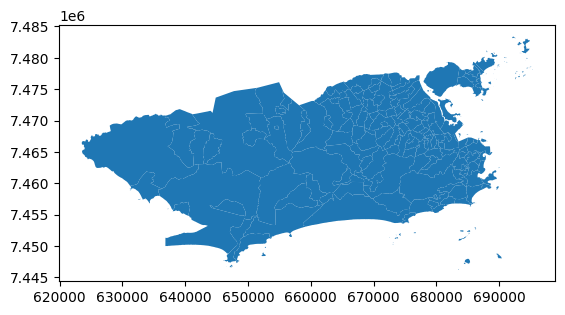

In [ ]:
bairros_full = bairros_shp.merge(votos_full[['BAIRRO', 'VOTOS_NOMINAIS_2020', 'VOTOS_NOMINAIS_2024']], how='left', on='BAIRRO')
bairros_full['VOTOS_NOMINAIS_2020'] = bairros_full['VOTOS_NOMINAIS_2020'].fillna(0)
bairros_full['VOTOS_NOMINAIS_2024'] = bairros_full['VOTOS_NOMINAIS_2024'].fillna(0)

In [ ]:
votos_full_select.to_csv('analise_votos_candidato_por_bairro.csv', index=False)

### Mapas comparativos 2020 vs 2024

In [ ]:
def criar_mapa_variacao(df=votos_full):
    # Garantir que é um GeoDataFrame
    if not isinstance(df, gpd.GeoDataFrame):
        gdf = gpd.GeoDataFrame(df, geometry='geometry')
    else:
        gdf = df.copy()

    # Criar mapa base centralizado no Rio de Janeiro
    m = folium.Map(
        location=[-22.9068, -43.1729],
        zoom_start=12,
        tiles='cartodbpositron'
    )

    # Encontrar o valor máximo absoluto para escala simétrica
    max_abs = max(abs(gdf['2024_vs_2020'].max()), abs(gdf['2024_vs_2020'].min()))

    # Criar escala de cores (vermelho para negativo, azul para positivo)
    colormap = LinearColormap(
        colors=['#d73027', '#f46d43', '#fdae61', '#fee090', '#ffffbf',
                '#e0f3f8', '#abd9e9', '#74add1', '#4575b4'],
        vmin=-max_abs,
        vmax=max_abs,
        caption='Variação de Votos 2024 vs 2020 (%)'
    )

    # Adicionar camada de polígonos
    folium.GeoJson(
        gdf,
        style_function=lambda feature: {
            'fillColor': colormap(feature['properties']['2024_vs_2020']),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['BAIRRO', '2024_vs_2020', 'VOTOS_NOMINAIS_2020', 'VOTOS_NOMINAIS_2024'],
            aliases=['Bairro:', 'Variação (%):', 'Votos 2020:', 'Votos 2024:'],
            localize=True,
            sticky=True
        )
    ).add_to(m)

    # Adicionar a legenda
    colormap.add_to(m)

    return display(m)

# Plotar o mapa
criar_mapa_variacao(votos_full_geometry)

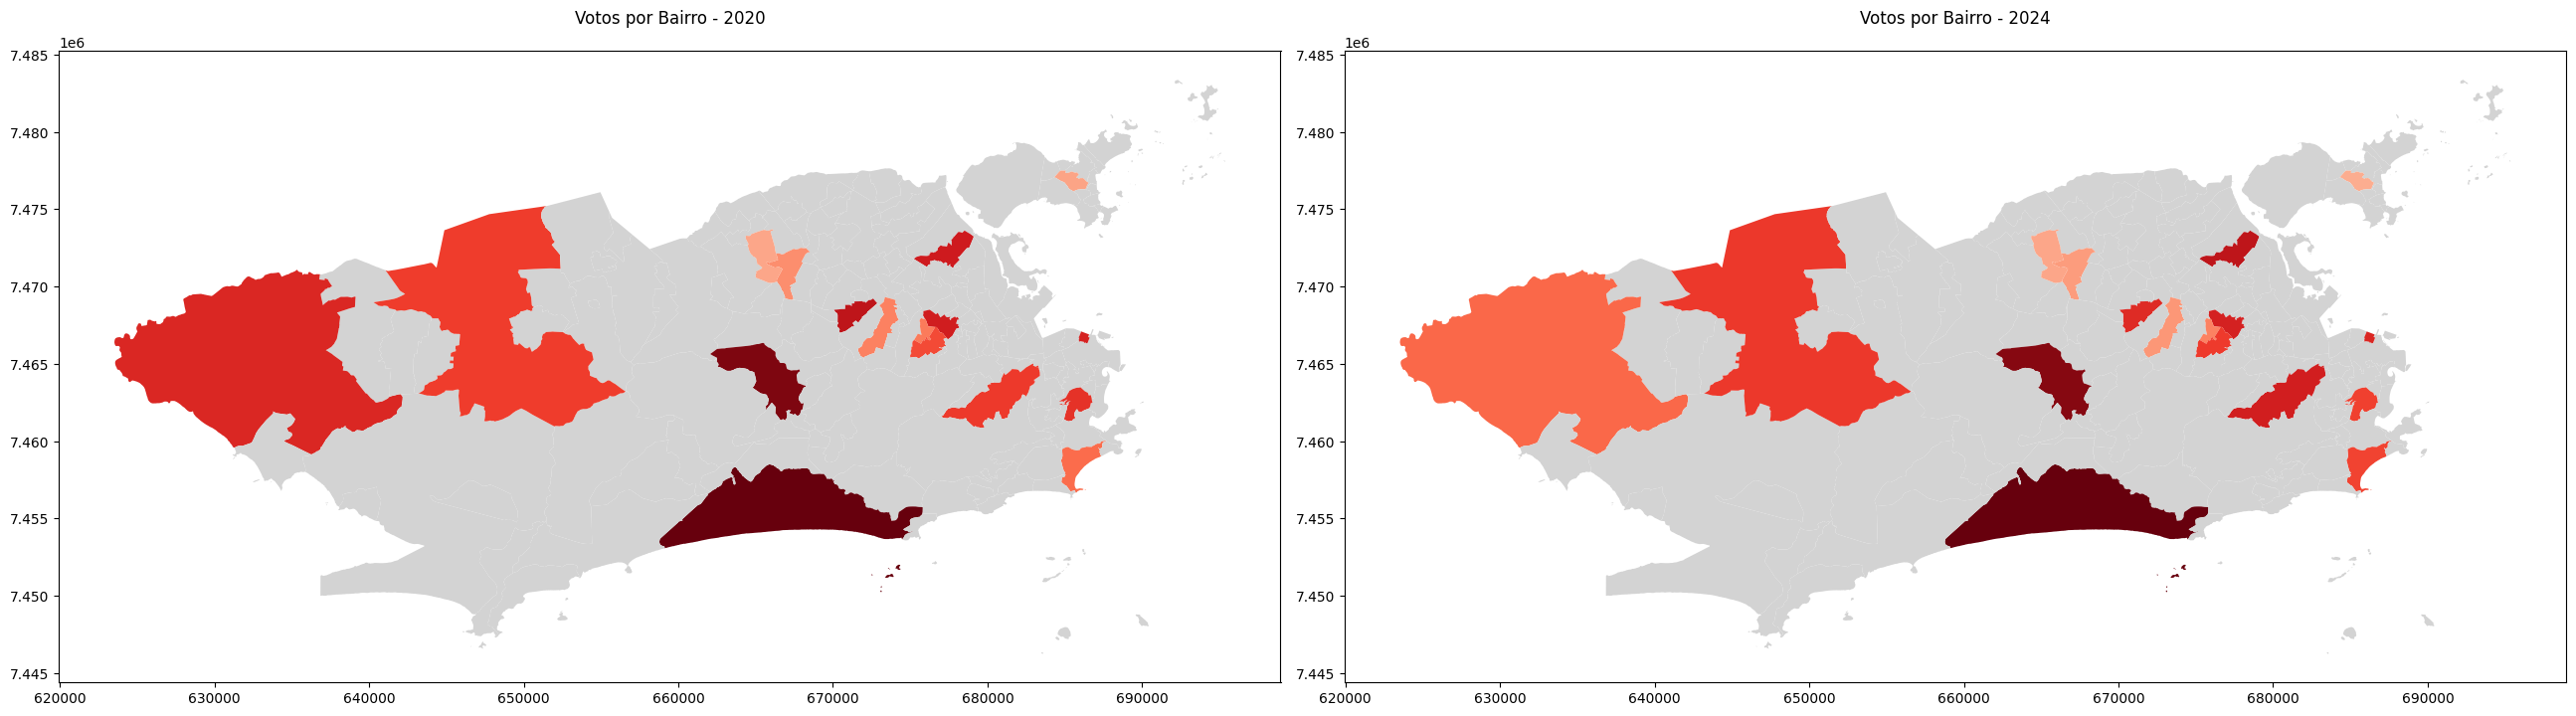

In [ ]:
def plotar_mapas_comparacao(df=bairros_full):
    # Garantir que é um GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry='geometry')

    # Configurar o tamanho da figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 8))

    # ALTERAÇÃO 1: Criar colormap personalizado com cinza para zero
    # Criar uma lista de cores do branco ao vermelho
    reds = plt.cm.Reds(np.linspace(0.2, 1, 256))[:-1]
    colors_list = np.concatenate([[colors.to_rgba('lightgrey')], reds])
    custom_cmap = colors.ListedColormap(colors_list)

    # Mapa 2020
    gdf.plot(
        column='VOTOS_NOMINAIS_2020',
        ax=ax1,
        legend=False,  # ALTERAÇÃO 2: Removida a legenda
        cmap=custom_cmap,  # ALTERAÇÃO 3: Usando o novo colormap
    )
    ax1.set_title('Votos por Bairro - 2020', pad=20)

    # Mapa 2024
    gdf.plot(
        column='VOTOS_NOMINAIS_2024',
        ax=ax2,
        legend=False,  # ALTERAÇÃO 2: Removida a legenda
        cmap=custom_cmap,  # ALTERAÇÃO 3: Usando o novo colormap
    )
    ax2.set_title('Votos por Bairro - 2024', pad=20)

    # Ajustar o layout
    plt.tight_layout()

    return plt.show()

# Plotar os mapas
plotar_mapas_comparacao(bairros_full)

In [ ]:
#criar uma análise geográfica por partido variação do partido por voto e variação

#criar um mapa comparativo do espectro


## Quem venceu mais: Esquerda ou Direita?

In [ ]:
candidatos_mais_votados_2020 = pd.read_csv(arquivo_prefeitos_mais_votados_1turno_2020)

In [ ]:
espec_type = pd.CategoricalDtype(categories=['direita', 'centro', 'esquerda'], ordered=True)

In [ ]:
candidatos_mais_votados_2020['Espectro'] = candidatos_mais_votados_2020['Espectro'].astype(espec_type)

In [ ]:
candidatos_mais_votados_2020.head()

,NM_URNA_CANDIDATO,NM_MUNICIPIO,CD_MUNICIPIO,DS_SIT_TOT_TURNO,NR_PARTIDO,SG_PARTIDO,QT_VOTOS_NOMINAIS,Espectro
0,BRUNO COVAS,SÃO PAULO,71072,2º TURNO,45,PSDB,1754013,centro
1,PAULO SERRA,SANTO ANDRÉ,70572,ELEITO,45,PSDB,266591,centro
2,ORLANDO MORANDO,SÃO BERNARDO DO CAMPO,70750,ELEITO,45,PSDB,261761,centro
3,FELICIO,SÃO JOSÉ DOS CAMPOS,70998,ELEITO,45,PSDB,204800,centro
4,ALVARO DIAS,NATAL,17612,ELEITO,45,PSDB,194764,centro


In [ ]:
municipios_geo_df = gpd.read_file(arquivo_BR_municipios_shapefile)
municipios_geo_df['NM_MUN'] = municipios_geo_df['NM_MUN'].str.upper()

In [ ]:
candidatos_mais_votados_2020_geo_df = municipios_geo_df.merge(candidatos_mais_votados_2020, left_on='NM_MUN', right_on='NM_MUNICIPIO')

<Axes: title={'center': 'Espectro Prefeitos Mais Votados por Município (2020)'}>

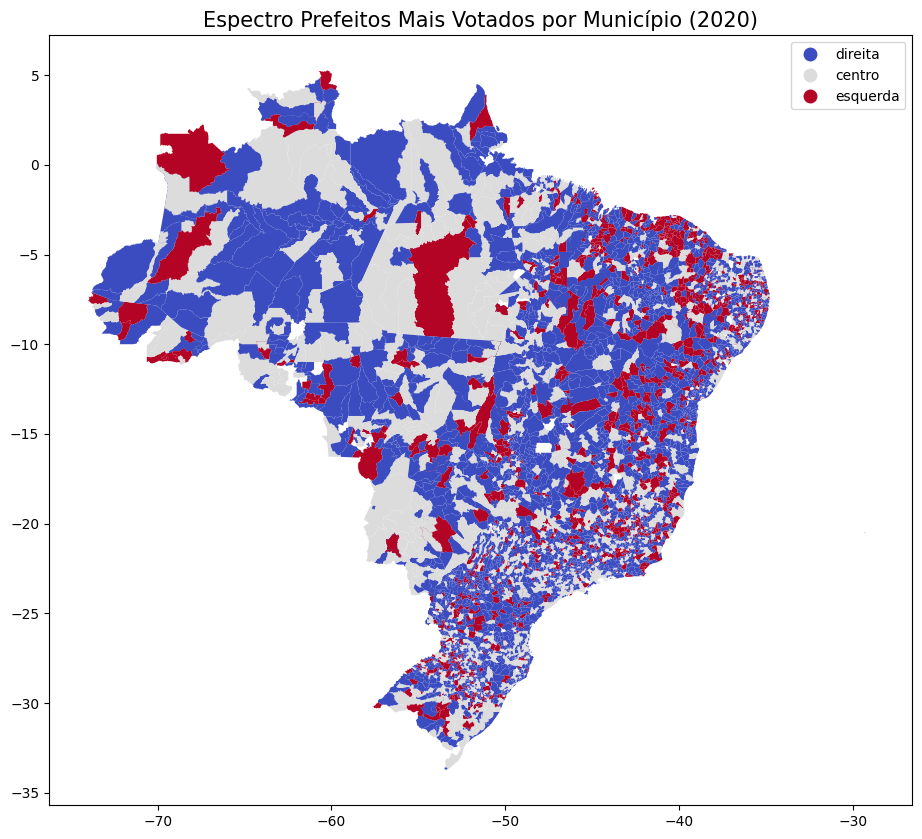

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(28,10))
ax.set_title(f'Espectro Prefeitos Mais Votados por Município (2020)',  size=15)

candidatos_mais_votados_2020_geo_df.plot(column='Espectro', legend=True, cmap='coolwarm', ax=ax)

In [ ]:
candidatos_mais_votados_2020_geo_df.Espectro.value_counts().plot(kind='bar',title=f'Prefeitos por Espectro Município (2020)')

#Comparando resultado das capitais em 2020 vs. 2024

## Resultado 2024

https://noticias.uol.com.br/eleicoes/2024/apuracao/

In [ ]:
# Extrair todas as divs da classe específica
divs = soup.find_all('div', class_='card-election')
#for div in divs:
    #print(div)

In [ ]:
cities = soup.find_all('p', class_='city my-0 no-link bold-text')
states = soup.find_all('p', class_='acronym regular-caption pl-50 my-0')
candidates = soup.find_all('p', class_='m-0 regular-text')
parties = soup.find_all('p', class_='avatar-description regular-smaller-text')
results_percent = soup.find_all('div', class_='result-item result-subtext with-values regular-text')
results_votes = soup.find_all('div', class_='result-item regular-caption result-caption')

In [ ]:
# Inicializa listas para armazenar os dados
municipios = []
estados = []
candidatos = []
partidos = []
votos_totais = []
votos_percentuais = []

In [ ]:
for candidate in candidates:
    candidatos.append(candidate.text)

for party in parties:
    partidos.append(party.text)

for city in cities:
    municipios.append(city.text)
    municipios.append(city.text)

for state in states:
    estados.append(state.text)
    estados.append(state.text)

for result in results_percent:
    votos_percentuais.append(result.text)

for result in results_votes:
    votos_totais.append(result.text)

In [ ]:
data = {
    'Municipio': municipios,
    'Estado': estados,
    'Candidato': candidatos,
    'Partido': partidos,
    'Votos-Totais': votos_totais,
    'Votos-Percentuais': votos_percentuais
}

resultado_2024 = pd.DataFrame(data)

In [ ]:
resultado_2024

,Municipio,Estado,Candidato,Partido,Votos-Totais,Votos-Percentuais
0,Vitória da Conquista,BA,Sheila Lemos,UNIÃO,116.488,"58,83%"
1,Vitória da Conquista,BA,Waldenor,PT,52.947,"26,74%"
2,São Paulo,SP,Ricardo Nunes,MDB,1.801.139,"29,48%"
3,São Paulo,SP,Guilherme Boulos,PSOL,1.776.127,"29,07%"
4,Belo Horizonte,MG,Bruno Engler,PL,435.853,"34,38%"
...,...,...,...,...,...,...
201,Foz do Iguaçu,PR,Paulo Mac Donald,PP,47.775,"32,58%"
202,Magé,RJ,Renato Cozzolino E,PP,125.902,"88,74%"
203,Magé,RJ,Ricardo da Karol,PL,12.146,"8,56%"
204,Parauapebas,PA,Aurélio Goiano E,AVANTE,92.073,"58,52%"


In [ ]:
resultado_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Municipio          206 non-null    object
 1   Estado             206 non-null    object
 2   Candidato          206 non-null    object
 3   Partido            206 non-null    object
 4   Votos-Totais       206 non-null    object
 5   Votos-Percentuais  206 non-null    object
dtypes: object(6)
memory usage: 9.8+ KB


In [ ]:
resultado_2024['Votos-Percentuais'] = resultado_2024['Votos-Percentuais'].str.replace('%','')
resultado_2024['Votos-Percentuais'] = resultado_2024['Votos-Percentuais'].str.replace(',','.').astype(float)
resultado_2024['Votos-Totais'] = resultado_2024['Votos-Totais'].str.replace('.','').astype(int)

In [ ]:
resultado_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Municipio          206 non-null    object 
 1   Estado             206 non-null    object 
 2   Candidato          206 non-null    object 
 3   Partido            206 non-null    object 
 4   Votos-Totais       206 non-null    int64  
 5   Votos-Percentuais  206 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 9.8+ KB


In [ ]:
resultado_2024.head()

,Municipio,Estado,Candidato,Partido,Votos-Totais,Votos-Percentuais
0,Vitória da Conquista,BA,Sheila Lemos,UNIÃO,116488,58.83
1,Vitória da Conquista,BA,Waldenor,PT,52947,26.74
2,São Paulo,SP,Ricardo Nunes,MDB,1801139,29.48
3,São Paulo,SP,Guilherme Boulos,PSOL,1776127,29.07
4,Belo Horizonte,MG,Bruno Engler,PL,435853,34.38


In [ ]:
partidos_df = pd.read_csv(arquivo_partidos, sep=';')
partidos_df['Espectro'] = partidos_df ['Espectro'].astype(espec_type)

In [ ]:
partidos_df.head()

,Espectro,SG_PARTIDO_TR,SG_PARTIDO,NR_PARTIDO
0,centro,AVANTE,AVANTE,70
1,direita,DC,DC,27
2,direita,DEM,DEM,25
3,centro,MDB,MDB,15
4,direita,NOVO,NOVO,30


In [ ]:
resultado_2024 = resultado_2024.\
merge(partidos_df, left_on='Partido', right_on='SG_PARTIDO')[['Municipio', 'Estado', 'Candidato', 'Partido', 'Votos-Totais',
       'Votos-Percentuais', 'Espectro','NR_PARTIDO']]

KeyError: "['Espectro', 'NR_PARTIDO'] not in index"

In [ ]:
resultado_2024.head()

,Municipio,Estado,Candidato,Partido,Votos-Totais,Votos-Percentuais,Espectro,NR_PARTIDO,Capital
0,Vitória da Conquista,BA,Sheila Lemos,UNIÃO,116488,58.83,direita,44,0
1,Vitória da Conquista,BA,Waldenor,PT,52947,26.74,esquerda,13,0
2,São Paulo,SP,Ricardo Nunes,MDB,1801139,29.48,centro,15,1
3,São Paulo,SP,Guilherme Boulos,PSOL,1776127,29.07,esquerda,50,1
4,Belo Horizonte,MG,Bruno Engler,PL,435853,34.38,direita,22,1


In [ ]:
capitais = pd.read_csv(arquivo_capitais)

In [ ]:
capitais.head()

,Municipio,Estado,Capital
0,Vitória da Conquista,BA,0
1,São Paulo,SP,1
2,Belo Horizonte,MG,1
3,Fortaleza,CE,1
4,Manaus,AM,1


In [ ]:
resultado_2024 = resultado_2024.\
merge(capitais[['Municipio','Capital']], on='Municipio')

In [ ]:
resultado_2024.head()

,Municipio,Estado,Candidato,Partido,Votos-Totais,Votos-Percentuais,Espectro,NR_PARTIDO,Capital_x,Capital_y
0,Vitória da Conquista,BA,Sheila Lemos,UNIÃO,116488,58.83,direita,44,0,0
1,Vitória da Conquista,BA,Waldenor,PT,52947,26.74,esquerda,13,0,0
2,São Paulo,SP,Ricardo Nunes,MDB,1801139,29.48,centro,15,1,1
3,São Paulo,SP,Guilherme Boulos,PSOL,1776127,29.07,esquerda,50,1,1
4,Belo Horizonte,MG,Bruno Engler,PL,435853,34.38,direita,22,1,1


In [ ]:
resultado_capitais_2024 = resultado_2024[resultado_2024['Capital'] == 1]

# Para cada combinação de 'Municipio' e 'Estado', encontra o índice da linha com o maior número de 'Votos-Totais'
idx = resultado_capitais_2024 .groupby(['Municipio', 'Estado'])['Votos-Totais'].idxmax()

# Usa os índices para filtrar o DataFrame original e obter todas as colunas
candidatos_mais_votados_capitais_2024 = resultado_capitais_2024.loc[idx].sort_values(by='Votos-Totais', ascending=False).reset_index(drop=True)

KeyError: 'Capital'

In [ ]:
candidatos_mais_votados_capitais_2024

,Municipio,Estado,Candidato,Partido,Votos-Totais,Votos-Percentuais,Espectro,NR_PARTIDO,Capital
0,Rio de Janeiro,RJ,Eduardo Paes Reeleito,PSD,1861856,60.47,centro,55,1
1,São Paulo,SP,Ricardo Nunes,MDB,1801139,29.48,centro,15,1
2,Salvador,BA,Bruno Reis Reeleito,UNIÃO,1045690,78.67,direita,44,1
3,Recife,PE,João Campos Reeleito,PSB,725721,78.11,esquerda,40,1
4,Fortaleza,CE,André Fernandes,PL,562305,40.20,direita,22,1
5,Belo Horizonte,MG,Bruno Engler,PL,435853,34.38,direita,22,1
6,São Luís,MA,Eduardo Braide Reeleito,PSD,403981,70.12,centro,55,1
7,Maceió,AL,JHC Reeleito,PL,379544,83.25,direita,22,1
8,Belém,PA,Igor,MDB,359904,44.89,centro,15,1
9,Manaus,AM,David Almeida,AVANTE,354596,32.16,centro,70,1


In [ ]:
estados_geo_df = gpd.read_file(arquivo_BR_estados_shapefile)

In [ ]:
estados_geo_df

,CD_UF,NM_UF,SIGLA_UF,NM_REGIAO,AREA_KM2,geometry
0,12,Acre,AC,Norte,164173.429,"POLYGON ((-68.79282 -10.99957, -68.79367 -10.9..."
1,13,Amazonas,AM,Norte,1559255.881,"POLYGON ((-56.76292 -3.23221, -56.76789 -3.242..."
2,15,Pará,PA,Norte,1245870.704,"MULTIPOLYGON (((-48.97548 -0.19834, -48.97487 ..."
3,16,Amapá,AP,Norte,142470.762,"MULTIPOLYGON (((-51.04561 -0.05088, -51.05422 ..."
4,17,Tocantins,TO,Norte,277423.627,"POLYGON ((-48.2483 -13.19239, -48.24844 -13.19..."
5,21,Maranhão,MA,Nordeste\n,329651.496,"MULTIPOLYGON (((-44.5868 -2.23341, -44.58696 -..."
6,22,Piauí,PI,Nordeste\n,251755.481,"POLYGON ((-42.47034 -3.48377, -42.46126 -3.484..."
7,23,Ceará,CE,Nordeste\n,148894.447,"POLYGON ((-37.87162 -4.3664, -37.87109 -4.3670..."
8,24,Rio Grande do Norte,RN,Nordeste\n,52809.599,"MULTIPOLYGON (((-35.18728 -5.78987, -35.18707 ..."
9,25,Paraíba,PB,Nordeste\n,56467.242,"MULTIPOLYGON (((-34.7958 -7.175, -34.79578 -7...."


<Axes: >

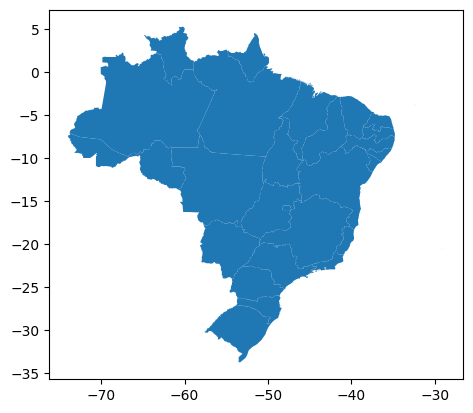

In [ ]:
estados_geo_df.plot()

In [ ]:
candidatos_mais_votados_capitais_2024_geo_df = estados_geo_df.merge(candidatos_mais_votados_capitais_2024 , left_on='SIGLA_UF', right_on='Estado')

<Axes: title={'center': 'Espectro do Prefeito mais votado da capital da UF (2024)'}>

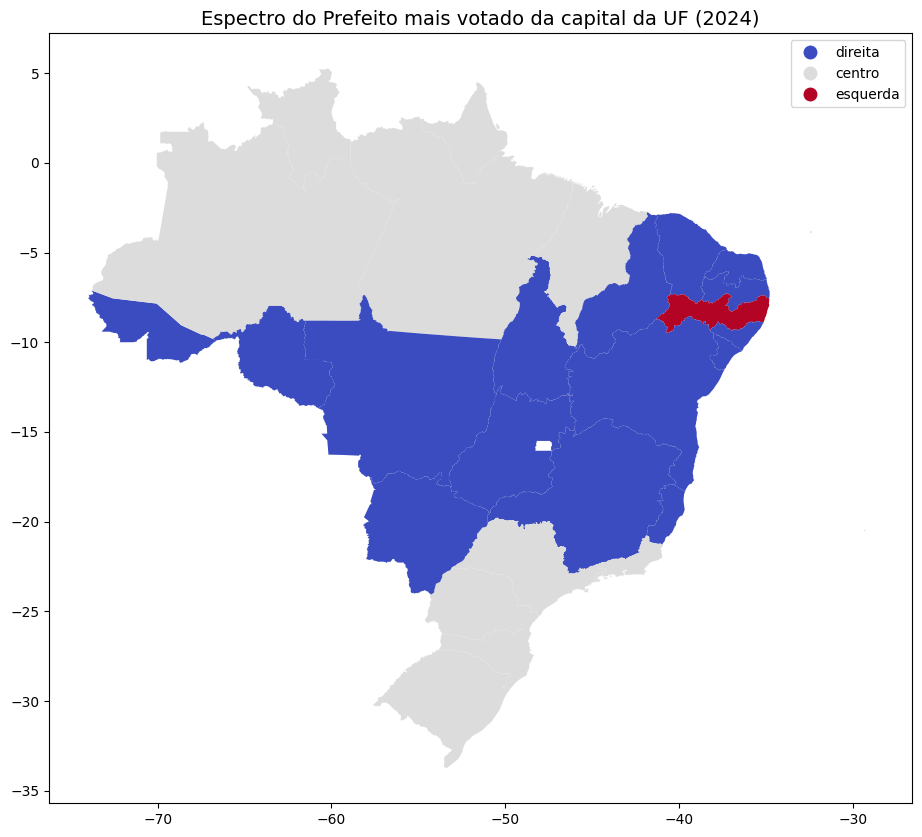

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(28,10))
ax.set_title(f'Espectro do Prefeito mais votado da capital da UF (2024)',size=14)

candidatos_mais_votados_capitais_2024_geo_df.plot(column='Espectro', legend=True, cmap='coolwarm', ax=ax)

In [ ]:
candidatos_mais_votados_capitais_2024_geo_df.Espectro.value_counts().plot(kind='bar',title=f'Prefeitos de Capitais por Espectro Município (2024)')

## Resultado 2020

In [ ]:
municipios_tse_df = pd.read_csv(arquivo_municipios_tse)

In [ ]:
municipios_tse_df

,codigo_tse,uf,nome_municipio,capital,codigo_ibge
0,1120,AC,ACRELÂNDIA,0,1200013
1,1570,AC,ASSIS BRASIL,0,1200054
2,1058,AC,BRASILÉIA,0,1200104
3,1007,AC,BUJARI,0,1200138
4,1015,AC,CAPIXABA,0,1200179
...,...,...,...,...,...
5565,96199,TO,TOCANTÍNIA,0,1721109
5566,73458,TO,TUPIRAMA,0,1721257
5567,73237,TO,TUPIRATINS,0,1721307
5568,96652,TO,WANDERLÂNDIA,0,1722081


In [ ]:
candidatos_mais_votados_1turno_2020 = candidatos_mais_votados_2020.merge(municipios_tse_df, left_on='CD_MUNICIPIO', right_on='codigo_tse')

In [ ]:
candidatos_mais_votados_capitais_1turno_2020 = candidatos_mais_votados_1turno_2020[candidatos_mais_votados_1turno_2020 ['capital']==1]

In [ ]:
candidatos_mais_votados_capitais_1turno_2020.head()

,NM_URNA_CANDIDATO,NM_MUNICIPIO,CD_MUNICIPIO,DS_SIT_TOT_TURNO,NR_PARTIDO,SG_PARTIDO,QT_VOTOS_NOMINAIS,Espectro,codigo_tse,uf,nome_municipio,capital,codigo_ibge
0,BRUNO COVAS,SÃO PAULO,71072,2º TURNO,45,PSDB,1754013,centro,71072,SP,SÃO PAULO,1,3550308
4,ALVARO DIAS,NATAL,17612,ELEITO,45,PSDB,194764,centro,17612,RN,NATAL,1,2408102
14,HILDON CHAVES,PORTO VELHO,35,2º TURNO,45,PSDB,74728,centro,35,RO,PORTO VELHO,1,1100205
26,CINTHIA RIBEIRO,PALMAS,73440,ELEITO,45,PSDB,46243,centro,73440,TO,PALMAS,1,1721000
528,EDUARDO PAES,RIO DE JANEIRO,60011,2º TURNO,25,DEM,974804,direita,60011,RJ,RIO DE JANEIRO,1,3304557


In [ ]:
candidatos_mais_votados_capitais_1turno_2020_geo_df = estados_geo_df.merge(candidatos_mais_votados_capitais_1turno_2020, left_on='SIGLA_UF', right_on='uf')

<Axes: title={'center': 'Espectro do Prefeito mais votado da capital da UF (1o turno - 2024)'}>

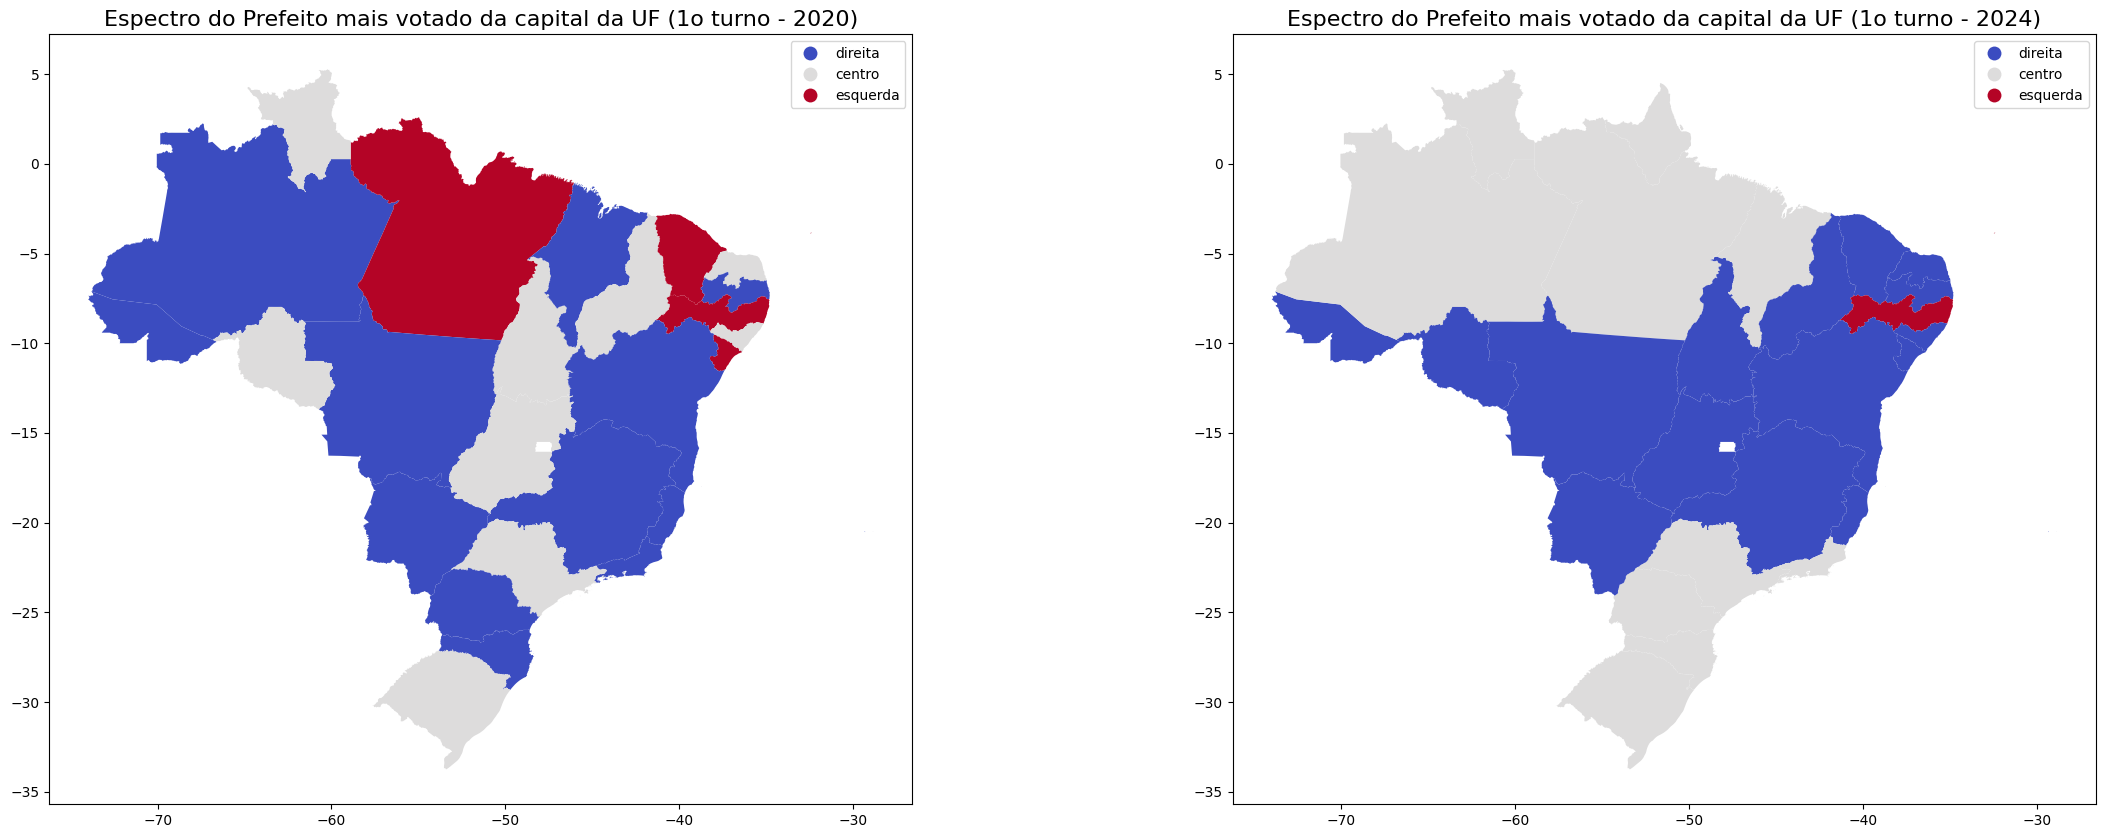

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(28,10))
ax[0].set_title(f'Espectro do Prefeito mais votado da capital da UF (1o turno - 2020)',size=16)
ax[1].set_title(f'Espectro do Prefeito mais votado da capital da UF (1o turno - 2024)',size=16)

candidatos_mais_votados_capitais_1turno_2020_geo_df .plot(column='Espectro', legend=True, cmap='coolwarm', ax=ax[0])
candidatos_mais_votados_capitais_2024_geo_df.plot(column='Espectro', legend=True, cmap='coolwarm', ax=ax[1])